In [1]:
import numpy as np 
import pandas as pd

import scanpy as sc 
import anndata as ann 

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import umap 

# Hacky within notebook installation of igraph 
%pip install igraph
%pip install leidenalg

######## writing this here so we do not lose track
np.random.seed(17)

/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os 

# Define working directory
os.chdir('../../../../snakemake_outfiles/apr16_real_results/andoizum/scratch/results/control/integrated_results/')
# Start by reading the files from the results dir
results_files = os.listdir()
results_files[0:5]

['pbmc_2_batch_hierarchical_balanced_1_celltypes_0.1_downsample_1_batch_ds_c_164_integrated_helical.h5ad',
 'pbmc_2_batch_base_balanced_1_celltypes_0_downsample_0_batch_ds_c_107_integrated_helical.h5ad',
 'pbmc_2_batch_hierarchical_balanced_1_celltypes_0.1_downsample_0_batch_ds_c_140_integrated_helical.h5ad',
 'pbmc_2_batch_base_balanced_1_celltypes_0_downsample_1_batch_ds_c_123_integrated_helical.h5ad',
 'pbmc_2_batch_hierarchical_balanced_1_celltypes_0.1_downsample_1_batch_ds_c_62_integrated_helical.h5ad']

In [3]:
# Group files based on control, downsampled and ablated 
control_files = [f for f in results_files if '0_batch_ds' in f]
ds_files = [f for f in results_files if '1_celltypes_0.1_downsample_1_batch_ds' in f]
ablated_files = [f for f in results_files if '1_celltypes_0_downsample_1_batch_ds' in f]

# Separating 2 batch based balanced from hierarchical balanced
control_files_base = [cf for cf in control_files if 'base' in cf]
ds_files_base = [dsf for dsf in ds_files if 'base' in dsf]
ablated_files_base = [af for af in ablated_files if 'base' in af]

# Check how many files we have for each experiment
len(control_files_base), len(ds_files_base), len(ablated_files_base)

(76, 47, 57)

In [4]:
# Randomly sample 45 control files, 45 downsampled files and 45 ablated files
# Because downsampling only has 47 files total
control_files_sample = np.random.choice(control_files_base, 45, replace=False)
ds_files_sample = np.random.choice(ds_files_base, 45, replace=False)
ablated_files_sample = np.random.choice(ablated_files_base, 45, replace=False)

# Load the files into a list of adata objects
control_adata = [sc.read(f) for f in control_files_sample]
ds_adata = [sc.read(f) for f in ds_files_sample]
ablated_adata = [sc.read(f) for f in ablated_files_sample]

/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/check_h5ad/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModifica

In [5]:
# Create a function that splits the anndatas into 3 anndatas based on the integration method 

def split_adata(adata):
    # Get the integration method from the obs attribute
    integration_method = adata.obs['integration_method'].values 
    
    # Subset the adata based on the integration method
    adata_uce = adata[integration_method == 'uce']
    adata_scgpt = adata[integration_method == 'scgpt']
    adata_geneformer = adata[integration_method == 'geneformer']
    
    return adata_uce, adata_scgpt, adata_geneformer

# Split the adata objects into 3 adata objects based on the integration method
control_adatas_uce = []
control_adatas_scgpt = []
control_adatas_geneformer = []

ds_adatas_uce = []
ds_adatas_scgpt = []
ds_adatas_geneformer = []

ablated_adatas_uce = []
ablated_adatas_scgpt = []
ablated_adatas_geneformer = []

# Loop through the control adata objects and split them
for adata in control_adata:
    adata_uce, adata_scgpt, adata_geneformer = split_adata(adata)
    control_adatas_uce.append(adata_uce)
    control_adatas_scgpt.append(adata_scgpt)
    control_adatas_geneformer.append(adata_geneformer)
    
for adata in ds_adata:
    adata_uce, adata_scgpt, adata_geneformer = split_adata(adata)
    ds_adatas_uce.append(adata_uce)
    ds_adatas_scgpt.append(adata_scgpt)
    ds_adatas_geneformer.append(adata_geneformer)
    
for adata in ablated_adata:
    adata_uce, adata_scgpt, adata_geneformer = split_adata(adata)
    ablated_adatas_uce.append(adata_uce)
    ablated_adatas_scgpt.append(adata_scgpt)
    ablated_adatas_geneformer.append(adata_geneformer)
    

In [6]:
control_adatas_uce

[View of AnnData object with n_obs × n_vars = 2400 × 33694
     obs: 'batch', 'celltype', 'total_counts', 'leiden', 'integration_method', 'kmeans_faiss'
     var: 'gene', 'index'
     uns: 'downsampling_stats'
     obsm: 'X_emb_reduced', 'X_umap'
     layers: 'raw',
 View of AnnData object with n_obs × n_vars = 2400 × 33694
     obs: 'batch', 'celltype', 'total_counts', 'leiden', 'integration_method', 'kmeans_faiss'
     var: 'gene', 'index'
     uns: 'downsampling_stats'
     obsm: 'X_emb_reduced', 'X_umap'
     layers: 'raw',
 View of AnnData object with n_obs × n_vars = 2400 × 33694
     obs: 'batch', 'celltype', 'total_counts', 'leiden', 'integration_method', 'kmeans_faiss'
     var: 'gene', 'index'
     uns: 'downsampling_stats'
     obsm: 'X_emb_reduced', 'X_umap'
     layers: 'raw',
 View of AnnData object with n_obs × n_vars = 2400 × 33694
     obs: 'batch', 'celltype', 'total_counts', 'leiden', 'integration_method', 'kmeans_faiss'
     var: 'gene', 'index'
     uns: 'downsampl

In [7]:
# Collect the adatas into a list of lists
adata_all = [control_adatas_uce, ds_adatas_uce, ablated_adatas_uce,
          control_adatas_scgpt, ds_adatas_scgpt, ablated_adatas_scgpt,
          control_adatas_geneformer, ds_adatas_geneformer, ablated_adatas_geneformer]

# Remove the old umap embeddings
for adata_list in adata_all:
    for adata in adata_list:
        if 'X_umap' in adata.obsm.keys():
            del adata.obsm['X_umap']

# function to visualize umap by celltype and by batch for all adatas in each array
# the figures will save into the same directory as the h5ad files
# if you want to run for a subset of data, subset the adata list before passing it to the function
def visualize_umap(adata_list, experiment_name):
    for idx, adata in enumerate(adata_list):
        sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_emb_reduced')
        sc.tl.umap(adata)
        
        sc.pl.umap(adata, 
                   color=['celltype'], 
                   title=f'{experiment_name} ({idx}) by Celltype', 
                   wspace=0.5,
                   save = f'{experiment_name}_{idx}_celltype.png') # where does this get saved
        
        sc.pl.umap(adata, 
                   color=['batch'], 
                   title=f'{experiment_name} ({idx}) by Batch', 
                   wspace=0.5,
                   save = f'{experiment_name}_{idx}_batch.png')
        
    return 0 # change this later

# commenting this out so i do not have to regenerate plots

# visualize_umap(control_adatas_uce, experiment_name = 'Control UCE');
# visualize_umap(ds_adatas_uce, experiment_name = 'Downsampled UCE');
# visualize_umap(ablated_adatas_uce, experiment_name = 'Ablated UCE');

# visualize_umap(control_adatas_scgpt, experiment_name = 'Control scGPT');
# visualize_umap(ds_adatas_scgpt, experiment_name = 'Downsampled scGPT');
# visualize_umap(ablated_adatas_scgpt, experiment_name = 'Ablated scGPT');

# visualize_umap(control_adatas_geneformer, experiment_name = 'Control Geneformer');
# visualize_umap(ds_adatas_geneformer, experiment_name = 'Downsampled Geneformer');
# visualize_umap(ablated_adatas_geneformer, experiment_name = 'Ablated Geneformer');

/var/folders/_5/5fls6c092nd2tmhs4rydngz00000gn/T/ipykernel_40153/408664068.py:10: ImplicitModificationWarning: Removing element `.obsm['X_umap']` of view, initializing view as actual.
  del adata.obsm['X_umap']


In [8]:
# Function to return counts of celltypes in anndata, per batch

def get_counts(adata):
    # Get the counts of celltypes in the adata object
    counts = adata.obs['celltype'].value_counts()
    
    # Return the counts as a dataframe
    df = pd.DataFrame(counts)
    
    return df

# Count the number of celltypes in the first control experiment, first downsampled experiment and first ablated experiment

control_counts = get_counts(control_adatas_uce[0])
ds_counts = get_counts(ds_adatas_uce[0])
ablated_counts = get_counts(ablated_adatas_uce[0])

# Print the counts
print('Control counts:')
print(control_counts)
print('Downsampled counts:')
print(ds_counts)
print('Ablated counts:')
print(ablated_counts)

Control counts:
                 count
celltype              
B cell             400
CD4 T cell         400
CD8 T cell         400
Monocyte_CD14      400
Monocyte_FCGR3A    400
NK cell            400
Downsampled counts:
                 count
celltype              
B cell             400
CD4 T cell         400
CD8 T cell         400
Monocyte_CD14      400
NK cell            400
Monocyte_FCGR3A    220
Ablated counts:
                 count
celltype              
B cell             400
CD8 T cell         400
Monocyte_CD14      400
Monocyte_FCGR3A    400
NK cell            400
CD4 T cell         200


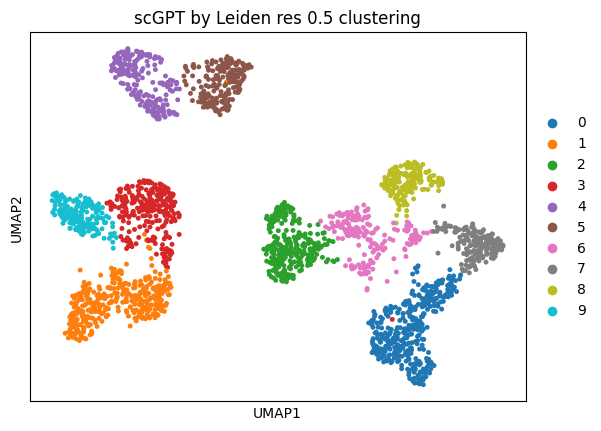

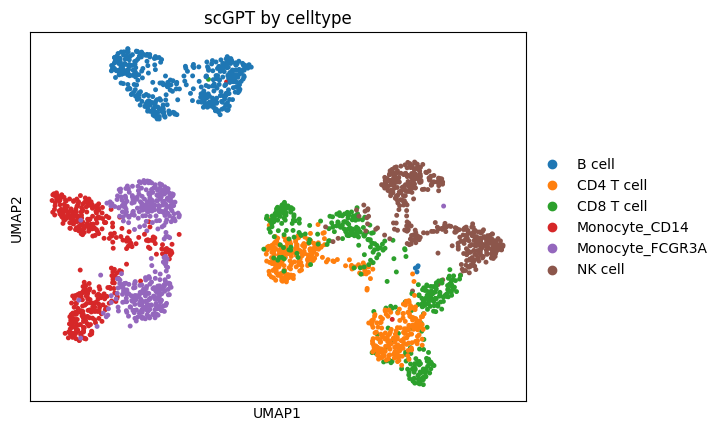

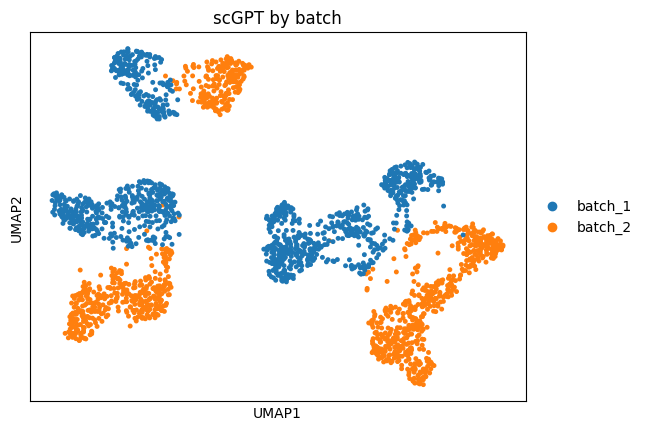

In [18]:
test_adata = control_adatas_scgpt[0]
sc.pp.neighbors(test_adata, n_neighbors=15, use_rep='X_emb_reduced')
sc.tl.leiden(test_adata, resolution=0.5)
sc.tl.umap(test_adata)

sc.pl.umap(test_adata, 
            color=['leiden'], 
            title=f'scGPT by Leiden res 0.5 clustering', 
            wspace=0.5) # where does this get saved
sc.pl.umap(test_adata, 
            color=['celltype'], 
            title=f'scGPT by celltype', 
            wspace=0.5) # where does this get saved

sc.pl.umap(test_adata, 
            color=['batch'], 
            title=f'scGPT by batch', 
            wspace=0.5) # where does this get saved

In [ ]:
# Create a function to calculate ARI and AMI for cell-type conservation (bio signal) and batch-correction (technical signal)

def get_metrics(adata):
    # Perform leiden clustering using the embedding information 
    sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_emb_reduced')
    sc.tl.leiden(adata, resolution=0.5) # originally 1.0
    
    # Get the celltype and batch labels
    celltype_labels = adata.obs['celltype'].values
    batch_labels = adata.obs['batch'].values
    
    # Get the leiden labels
    leiden_labels = adata.obs['leiden'].values
    
    # Calculate the ARI and AMI for cell-type conservation
    ari_celltype = adjusted_rand_score(celltype_labels, leiden_labels)
    ami_celltype = adjusted_mutual_info_score(celltype_labels, leiden_labels)
    
    # Calculate the ARI and AMI for batch-correction
    ari_batch = 1 - adjusted_rand_score(batch_labels, leiden_labels)
    ami_batch = 1 - adjusted_mutual_info_score(batch_labels, leiden_labels)
    
    # Find the cell type that hhas been downsampled or ablated
    counts = get_counts(adata)
    low_counts = counts[counts['count'] < 400]
    if low_counts.empty:
        reduced_celltype = "NA"
    else:
        reduced_celltype = low_counts.index[0]
    
    # Create a dictionary to store the metrics
    metrics = {
        'ari_celltype': ari_celltype,
        'ami_celltype': ami_celltype,
        'ari_batch': ari_batch,
        'ami_batch': ami_batch,
        'reduced_celltype': reduced_celltype
    }
    
    return metrics

In [14]:
# Loop through and calculate the metrics for each of the adata objects - for UCE, scGPT and Geneformer

control_metrics_uce = []
control_metrics_scgpt = []
control_metrics_geneformer = []

ds_metrics_uce = []
ds_metrics_scgpt = []
ds_metrics_geneformer = []

ablated_metrics_uce = []
ablated_metrics_scgpt = []
ablated_metrics_geneformer = []

# Loop through the control adata objects and calculate the metrics
for adata in control_adatas_uce:
    metrics = get_metrics(adata)
    control_metrics_uce.append(metrics)
    
for adata in control_adatas_scgpt:
    metrics = get_metrics(adata)
    control_metrics_scgpt.append(metrics)
    
for adata in control_adatas_geneformer:
    metrics = get_metrics(adata)
    control_metrics_geneformer.append(metrics)
    
for adata in ds_adatas_uce:
    metrics = get_metrics(adata)
    ds_metrics_uce.append(metrics)
    
for adata in ds_adatas_scgpt:
    metrics = get_metrics(adata)
    ds_metrics_scgpt.append(metrics)
    
for adata in ds_adatas_geneformer:
    metrics = get_metrics(adata)
    ds_metrics_geneformer.append(metrics)
    
for adata in ablated_adatas_uce:
    metrics = get_metrics(adata)
    ablated_metrics_uce.append(metrics)
    
for adata in ablated_adatas_scgpt:
    metrics = get_metrics(adata)
    ablated_metrics_scgpt.append(metrics)
    
for adata in ablated_adatas_geneformer:
    metrics = get_metrics(adata)
    ablated_metrics_geneformer.append(metrics)
    
# Create a function to convert the metrics to a dataframe
def metrics_to_df(metrics, integration_method, experiment):
    # Create a dataframe from the metrics
    df = pd.DataFrame(metrics)
    
    # Add the integration method to the dataframe
    df['integration_method'] = integration_method
    
    # Add the experiment type to the data frame
    df['experiment_type'] = experiment
    
    # Want to add the celltype being downsampled or ablated
    
    return df

# Convert the metrics to dataframes
control_metrics_uce_df = metrics_to_df(control_metrics_uce, integration_method = 'uce', experiment = 'control')
control_metrics_scgpt_df = metrics_to_df(control_metrics_scgpt, integration_method = 'scgpt', experiment = 'control')
control_metrics_geneformer_df = metrics_to_df(control_metrics_geneformer, integration_method = 'geneformer', experiment = 'control')

ds_metrics_uce_df = metrics_to_df(ds_metrics_uce, integration_method = 'uce', experiment = 'downsampled')
ds_metrics_scgpt_df = metrics_to_df(ds_metrics_scgpt, integration_method = 'scgpt', experiment = 'downsampled')
ds_metrics_geneformer_df = metrics_to_df(ds_metrics_geneformer, integration_method = 'geneformer', experiment = 'downsampled')

ablated_metrics_uce_df = metrics_to_df(ablated_metrics_uce, integration_method = 'uce', experiment = 'ablated')
ablated_metrics_scgpt_df = metrics_to_df(ablated_metrics_scgpt, integration_method = 'scgpt', experiment = 'ablated')
ablated_metrics_geneformer_df = metrics_to_df(ablated_metrics_geneformer, integration_method = 'geneformer', experiment = 'ablated')


# Concatenate the dataframes
metrics_df = pd.concat([control_metrics_uce_df, control_metrics_scgpt_df, control_metrics_geneformer_df,
                         ds_metrics_uce_df, ds_metrics_scgpt_df, ds_metrics_geneformer_df,
                         ablated_metrics_uce_df, ablated_metrics_scgpt_df, ablated_metrics_geneformer_df], axis=0)

In [15]:
metrics_df

# saving the dataframe to a csv file
metrics_df.to_csv('metrics_df.csv')

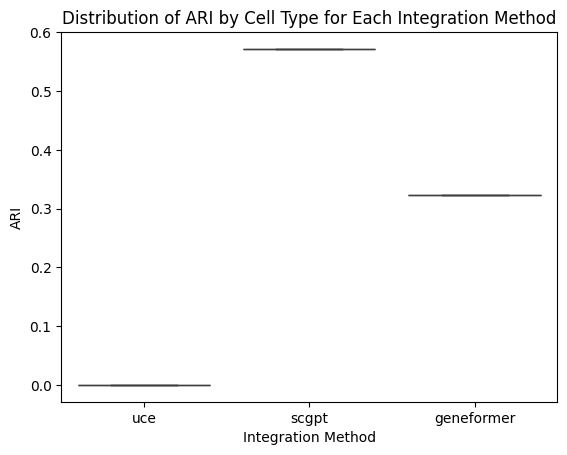

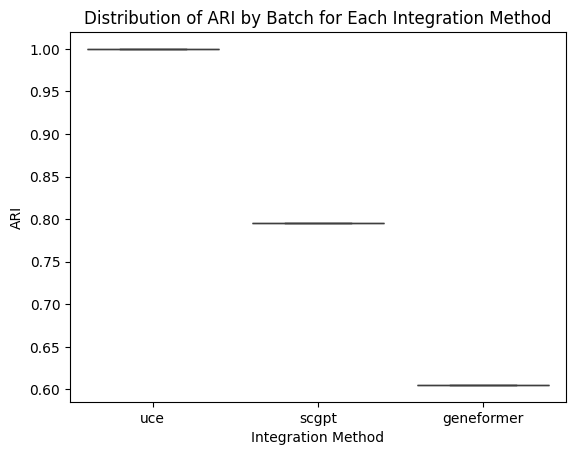

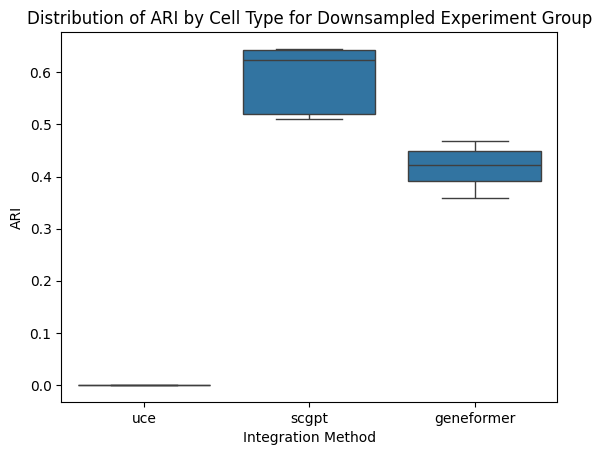

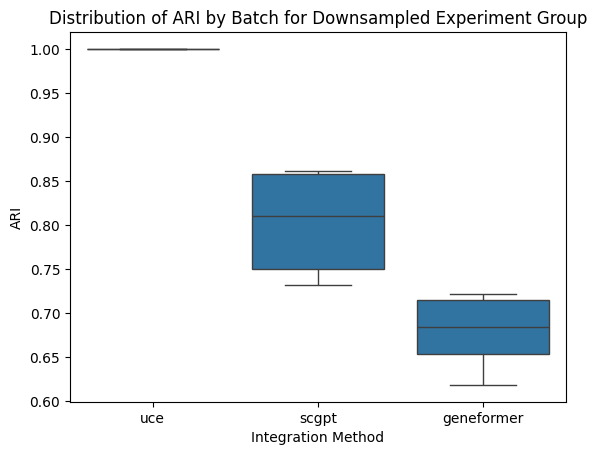

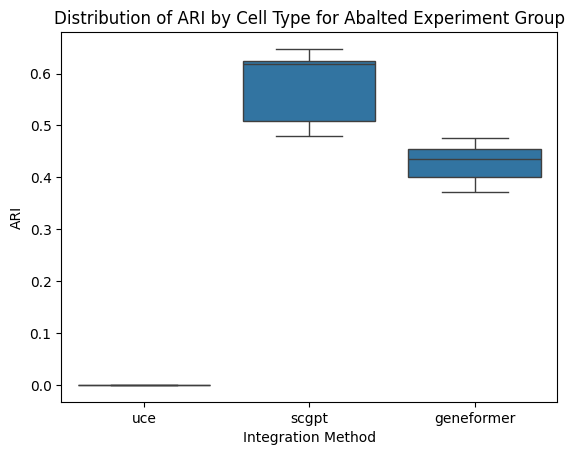

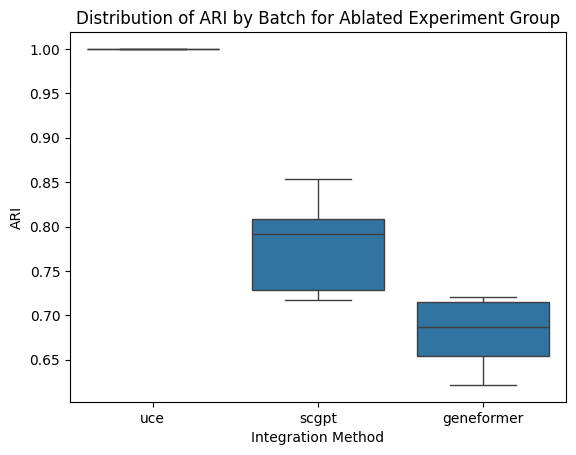

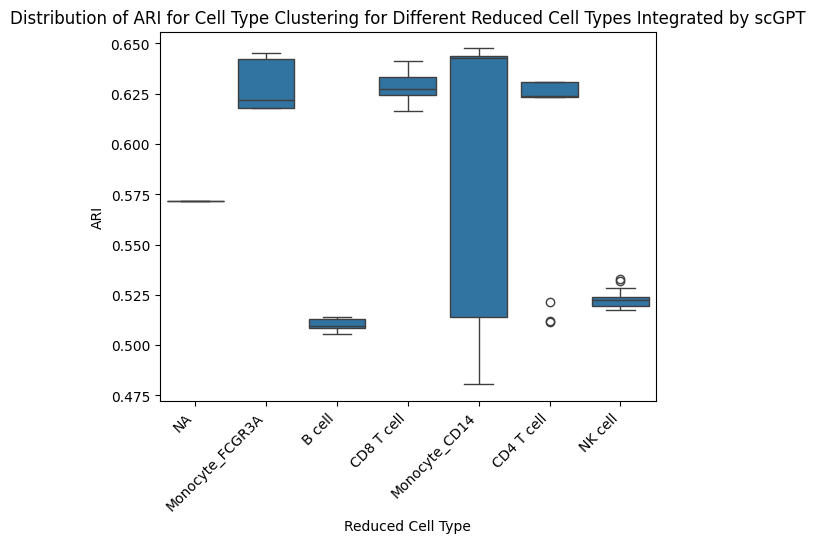

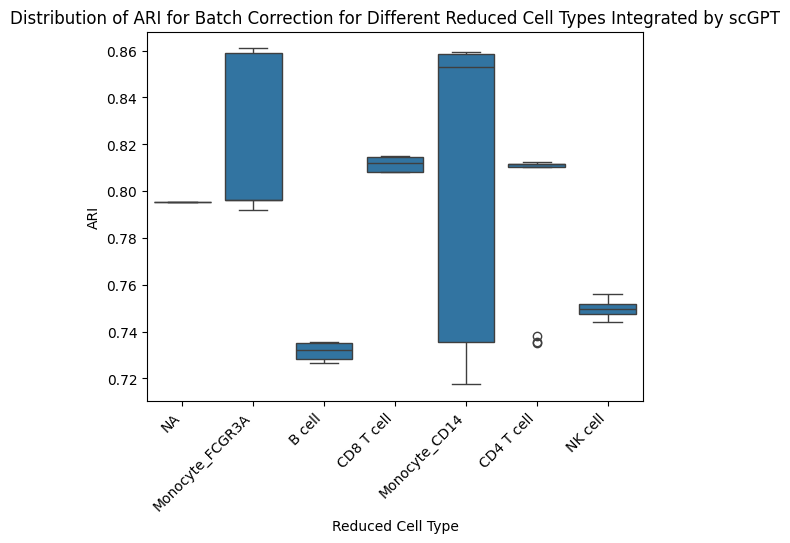

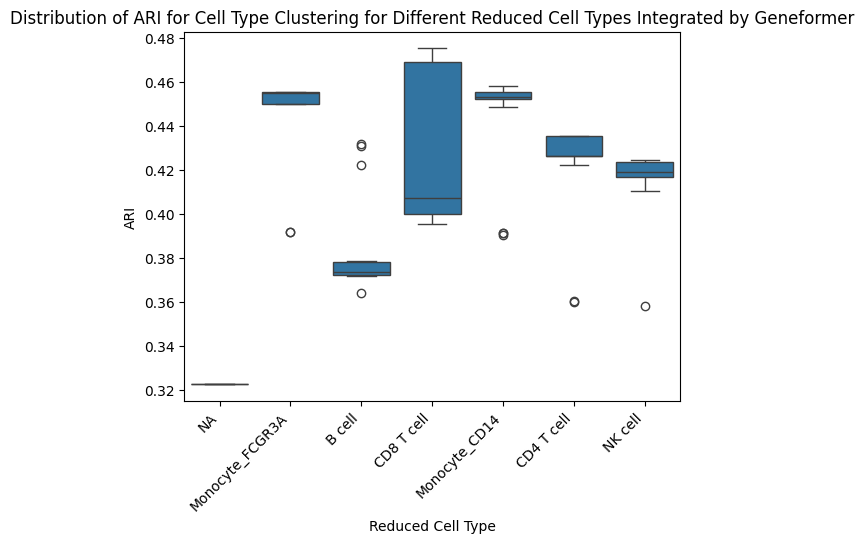

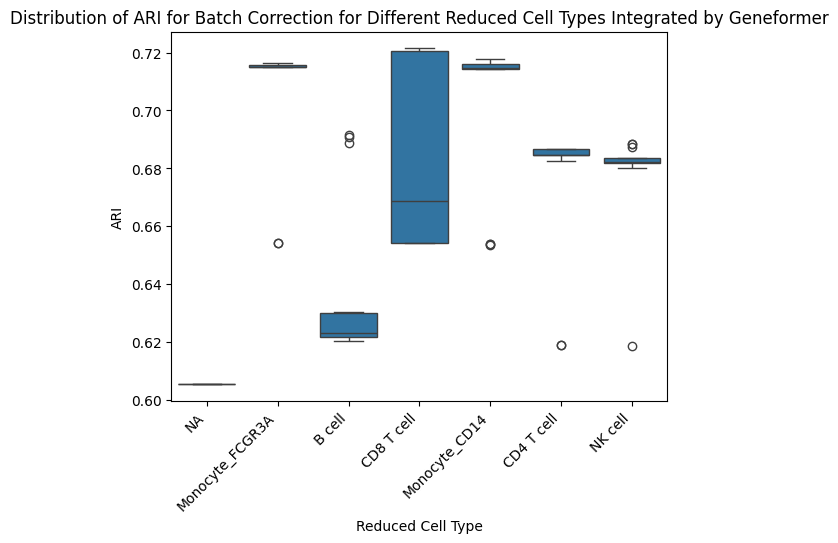

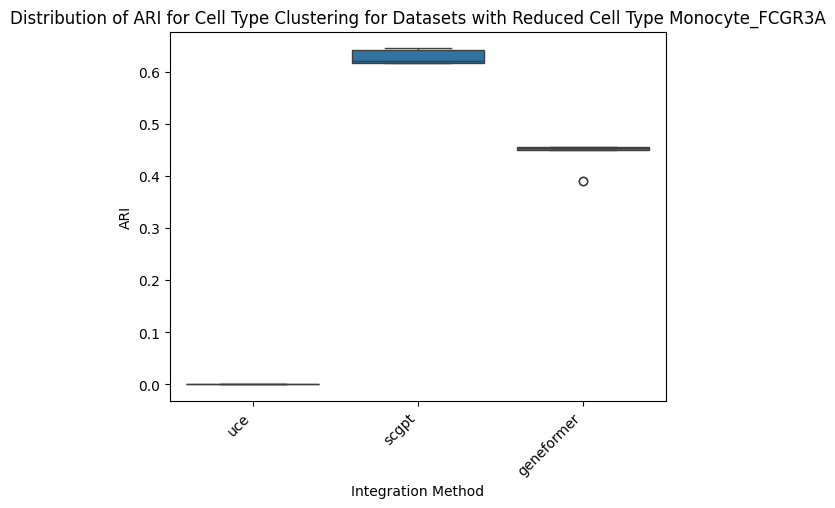

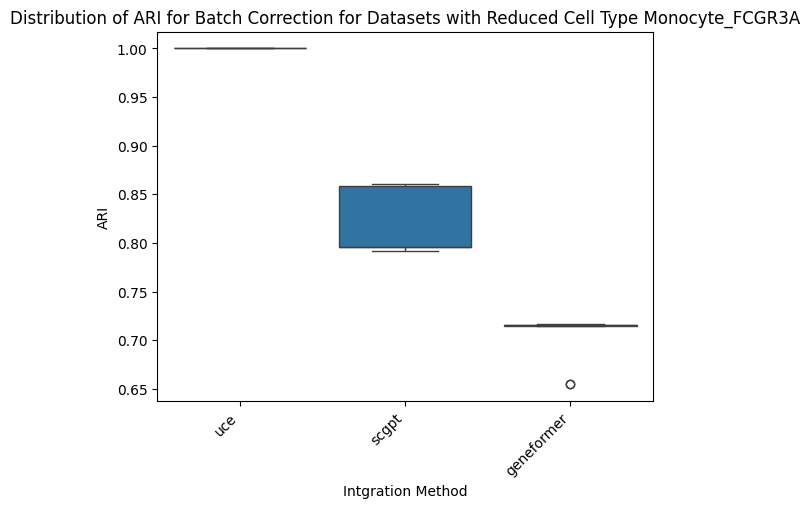

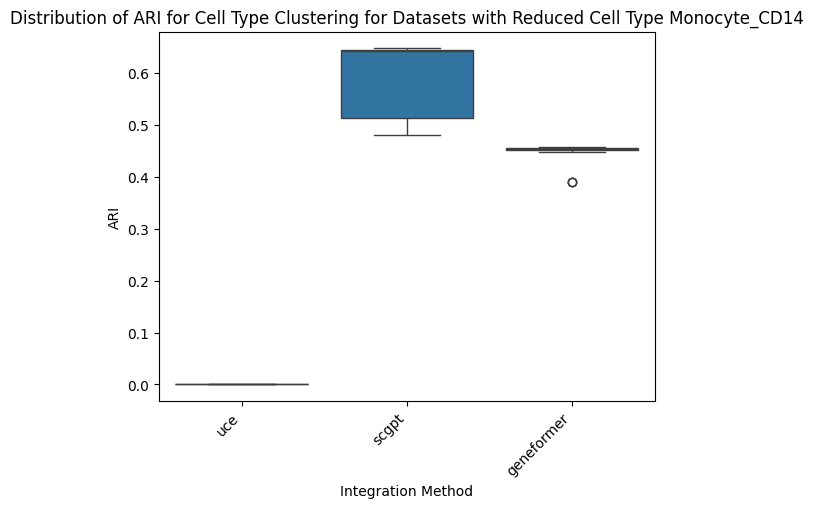

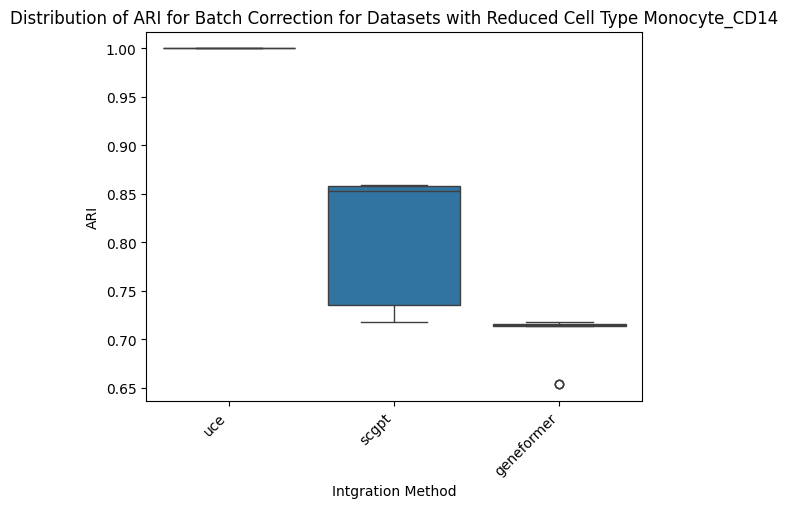

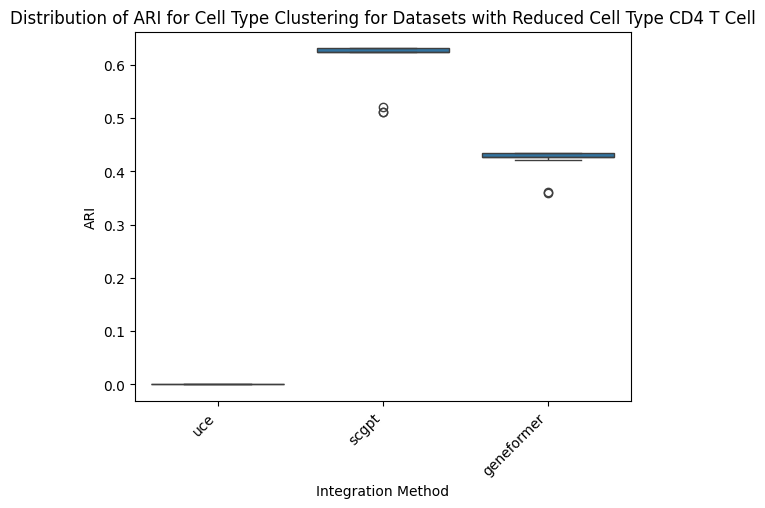

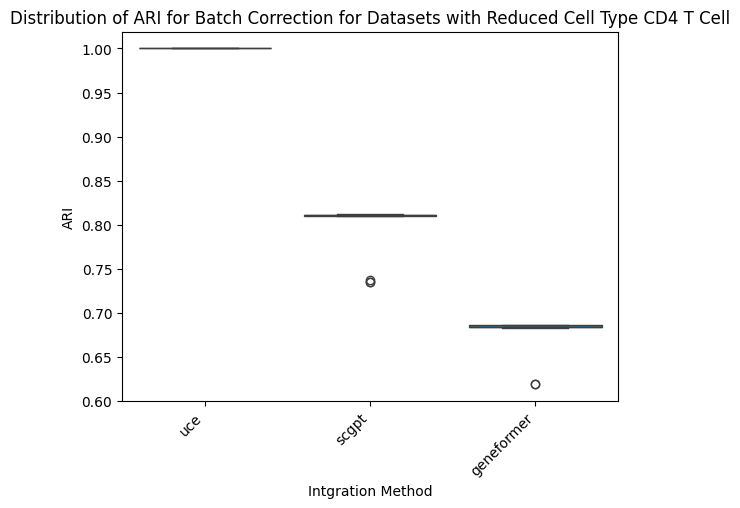

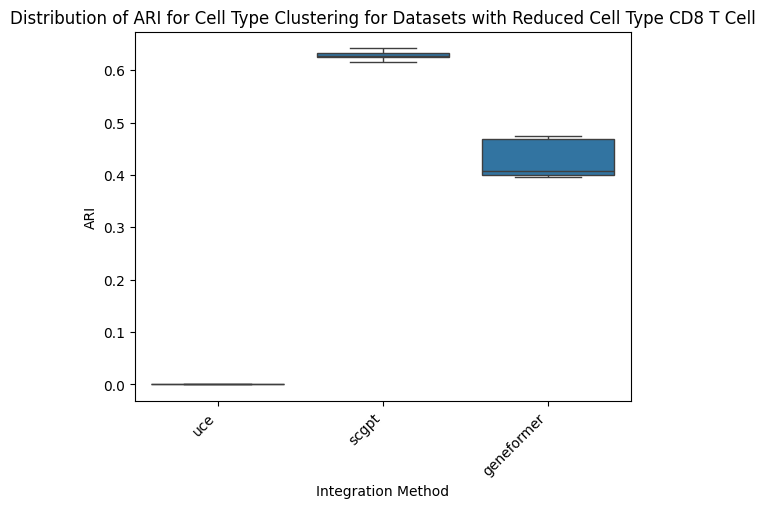

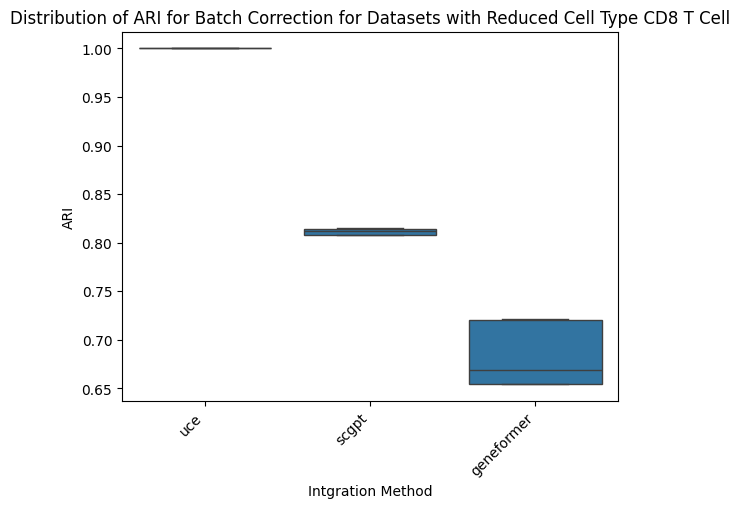

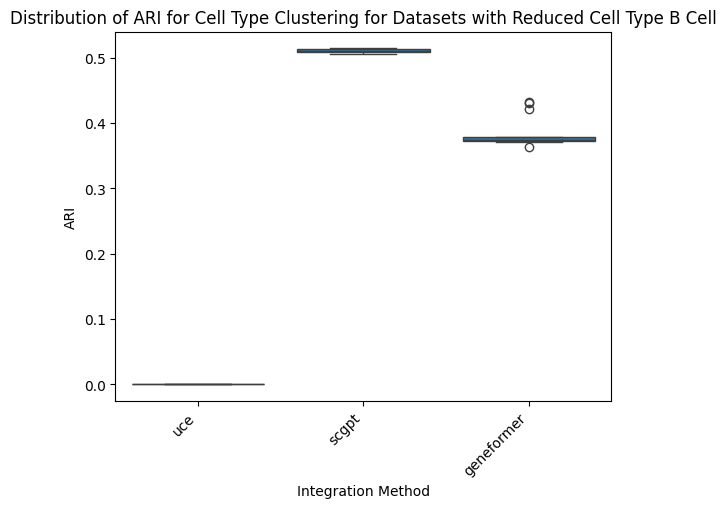

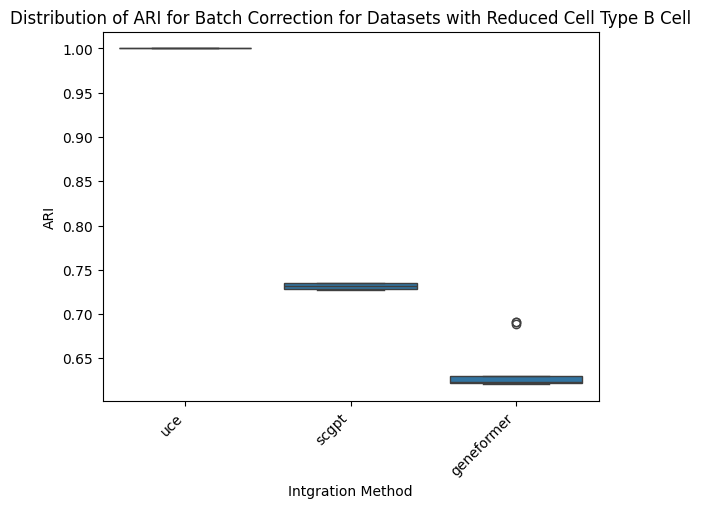

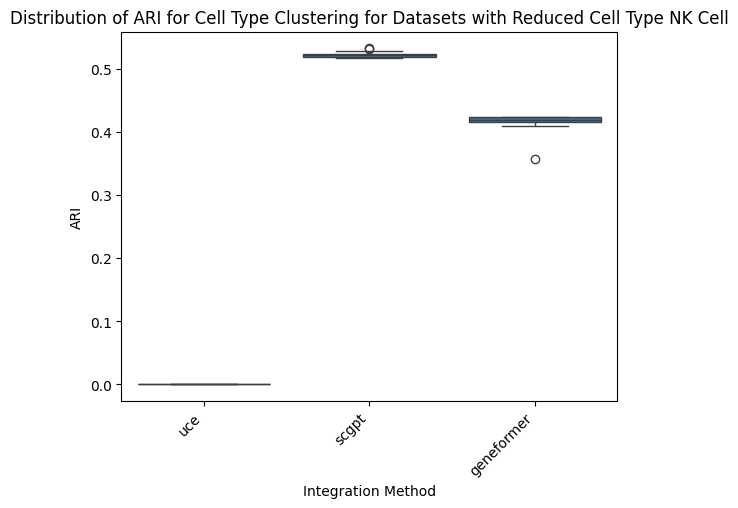

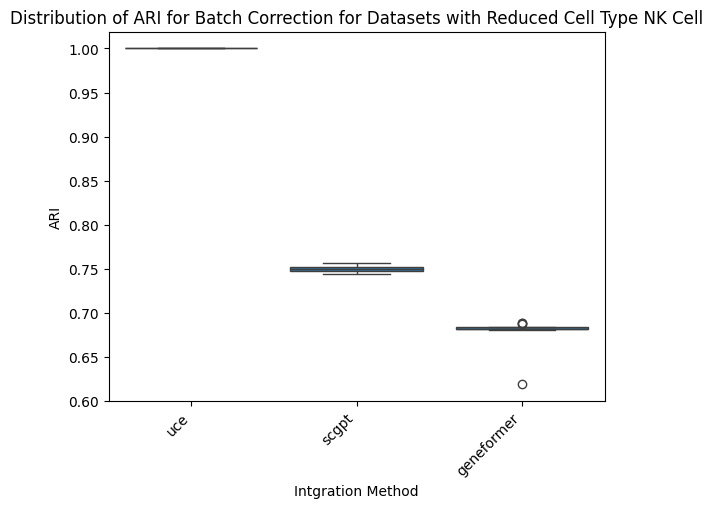

In [16]:
import matplotlib.pyplot as plt # move this to the top later
import seaborn as sns


# subset the data frame
control_metrics_df = metrics_df[metrics_df['experiment_type'] == 'control']
ds_metrics_df = metrics_df[metrics_df['experiment_type'] == 'downsampled']
ablated_metrics_df = metrics_df[metrics_df['experiment_type'] == 'ablated']
uce_metrics_df = metrics_df[metrics_df['integration_method'] == 'uce']
scgpt_metrics_df = metrics_df[metrics_df['integration_method'] == 'scgpt']
geneformer_metrics_df = metrics_df[metrics_df['integration_method'] == 'geneformer']
mono_f_metrics_df = metrics_df[metrics_df['reduced_celltype'] == 'Monocyte_FCGR3A']
bcell_metrics_df = metrics_df[metrics_df['reduced_celltype'] == 'B cell']
tcell_4_metrics_df = metrics_df[metrics_df['reduced_celltype'] == 'CD4 T cell']
mono_c_metrics_df = metrics_df[metrics_df['reduced_celltype'] == 'Monocyte_CD14']
tcell_8_metrics_df = metrics_df[metrics_df['reduced_celltype'] == 'CD8 T cell']
nkcell_metrics_df = metrics_df[metrics_df['reduced_celltype'] == 'NK cell']


# plot and save Figure 1: box plot of three model performances (batch and cell type)
# cell type conservation
sns.boxplot(x='integration_method', y='ari_celltype', data=control_metrics_df)
plt.title('Distribution of ARI by Cell Type for Each Integration Method')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.savefig('control_model_performance_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='integration_method', y='ari_batch', data=control_metrics_df)
plt.title('Distribution of ARI by Batch for Each Integration Method')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.savefig('control_model_performance_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# plot the ari for each experiment for each model 
# downsampled
# cell type conservation
sns.boxplot(x='integration_method', y='ari_celltype', data=ds_metrics_df)
plt.title('Distribution of ARI by Cell Type for Downsampled Experiment Group')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.savefig('ds_model_performance_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='integration_method', y='ari_batch', data=ds_metrics_df)
plt.title('Distribution of ARI by Batch for Downsampled Experiment Group')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.savefig('ds_model_performance_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# ablated
# cell type conservation
sns.boxplot(x='integration_method', y='ari_celltype', data=ablated_metrics_df)
plt.title('Distribution of ARI by Cell Type for Abalted Experiment Group')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.savefig('ablated_model_performance_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='integration_method', y='ari_batch', data=ablated_metrics_df)
plt.title('Distribution of ARI by Batch for Ablated Experiment Group')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.savefig('ablated_model_performance_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# scGPT
# cell type conservation
sns.boxplot(x='reduced_celltype', y='ari_celltype', data=scgpt_metrics_df)
plt.title('Distribution of ARI for Cell Type Clustering for Different Reduced Cell Types Integrated by scGPT')
plt.xlabel('Reduced Cell Type')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('scgpt_reduced_celltype_performance_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='reduced_celltype', y='ari_batch', data=scgpt_metrics_df)
plt.title('Distribution of ARI for Batch Correction for Different Reduced Cell Types Integrated by scGPT')
plt.xlabel('Reduced Cell Type')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('scgpt_reduced_celltype_performance_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# Geneformer
# cell type conservation
sns.boxplot(x='reduced_celltype', y='ari_celltype', data=geneformer_metrics_df)
plt.title('Distribution of ARI for Cell Type Clustering for Different Reduced Cell Types Integrated by Geneformer')
plt.xlabel('Reduced Cell Type')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('geneformer_reduced_celltype_performance_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='reduced_celltype', y='ari_batch', data=geneformer_metrics_df)
plt.title('Distribution of ARI for Batch Correction for Different Reduced Cell Types Integrated by Geneformer')
plt.xlabel('Reduced Cell Type')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('geneformer_reduced_celltype_performance_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# Monocyte_FCGR3A
# cell type conservation
sns.boxplot(x='integration_method', y='ari_celltype', data=mono_f_metrics_df)
plt.title('Distribution of ARI for Cell Type Clustering for Datasets with Reduced Cell Type Monocyte_FCGR3A')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('mono_f_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='integration_method', y='ari_batch', data=mono_f_metrics_df)
plt.title('Distribution of ARI for Batch Correction for Datasets with Reduced Cell Type Monocyte_FCGR3A')
plt.xlabel('Intgration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('mono_F_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# Monocyte_CD14
# cell type conservation
sns.boxplot(x='integration_method', y='ari_celltype', data=mono_c_metrics_df)
plt.title('Distribution of ARI for Cell Type Clustering for Datasets with Reduced Cell Type Monocyte_CD14')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('mono_c_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='integration_method', y='ari_batch', data=mono_c_metrics_df)
plt.title('Distribution of ARI for Batch Correction for Datasets with Reduced Cell Type Monocyte_CD14')
plt.xlabel('Intgration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('mono_c_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# tcell_4
# cell type conservation
sns.boxplot(x='integration_method', y='ari_celltype', data=tcell_4_metrics_df)
plt.title('Distribution of ARI for Cell Type Clustering for Datasets with Reduced Cell Type CD4 T Cell')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('tcell_4_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='integration_method', y='ari_batch', data=tcell_4_metrics_df)
plt.title('Distribution of ARI for Batch Correction for Datasets with Reduced Cell Type CD4 T Cell')
plt.xlabel('Intgration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('tcell_4_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# tcell_8
# cell type conservation
sns.boxplot(x='integration_method', y='ari_celltype', data=tcell_8_metrics_df)
plt.title('Distribution of ARI for Cell Type Clustering for Datasets with Reduced Cell Type CD8 T Cell')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('tcell_8_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='integration_method', y='ari_batch', data=tcell_8_metrics_df)
plt.title('Distribution of ARI for Batch Correction for Datasets with Reduced Cell Type CD8 T Cell')
plt.xlabel('Intgration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('tcell_8_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# B cell
# cell type conservation
sns.boxplot(x='integration_method', y='ari_celltype', data=bcell_metrics_df)
plt.title('Distribution of ARI for Cell Type Clustering for Datasets with Reduced Cell Type B Cell')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('bcell_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='integration_method', y='ari_batch', data=bcell_metrics_df)
plt.title('Distribution of ARI for Batch Correction for Datasets with Reduced Cell Type B Cell')
plt.xlabel('Intgration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('bcell_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# NK Cell
# cell type conservation
sns.boxplot(x='integration_method', y='ari_celltype', data=nkcell_metrics_df)
plt.title('Distribution of ARI for Cell Type Clustering for Datasets with Reduced Cell Type NK Cell')
plt.xlabel('Integration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('nkcell_celltype.png', dpi=300, bbox_inches='tight')
plt.show()
# batch correction
sns.boxplot(x='integration_method', y='ari_batch', data=nkcell_metrics_df)
plt.title('Distribution of ARI for Batch Correction for Datasets with Reduced Cell Type NK Cell')
plt.xlabel('Intgration Method')
plt.ylabel('ARI')
plt.xticks(rotation=45, ha='right')
plt.savefig('nkcell_batch.png', dpi=300, bbox_inches='tight')
plt.show()

# sns.boxplot(x='experiment_type', y='ari_batch', data=geneformer_metrics_df)
# plt.title('Boxplots for Each Integration Method')
# plt.xlabel('Integration Method')
# plt.ylabel('ARI')
# plt.show()